<a href="https://colab.research.google.com/github/RoihansLab/Data-Mining-Project/blob/main/Segmentasi_Konten_(niche)_yang_dibangun_oleh_Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2. Preprocessing Data**

In [198]:
import pandas as pd
df = pd.read_csv('/content/netflix.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2635 entries, 0 to 2634
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Film_ID          2635 non-null   int64  
 1   Title            2635 non-null   object 
 2   Content_Type     2635 non-null   object 
 3   Genre_Utama      2635 non-null   object 
 4   Related_Genre_1  2635 non-null   object 
 5   Related_Genre_2  2518 non-null   object 
 6   Related_Genre_3  2127 non-null   object 
 7   Related_Genre_4  1481 non-null   object 
 8   Related_Genre_5  911 non-null    object 
 9   Related_Genre_6  498 non-null    object 
 10  Related_Genre_7  244 non-null    object 
 11  Related_Genre_8  94 non-null     object 
 12  Age_Rating       2635 non-null   object 
 13  Release_Year     1257 non-null   float64
 14  Seasons          780 non-null    float64
 15  Synopsis         2635 non-null   object 
 16  Cast             2338 non-null   object 
 17  Director      

In [199]:
df

,Film_ID,Title,Content_Type,Genre_Utama,Related_Genre_1,Related_Genre_2,Related_Genre_3,Related_Genre_4,Related_Genre_5,Related_Genre_6,...,Age_Rating,Release_Year,Seasons,Synopsis,Cast,Director,Moods,Audio,Subtitles,URL
0,81266458,Time to Hunt,Movie,Thrillers,Korean,Thriller Movies,NaN,NaN,NaN,NaN,...,TV-MA,2020.0,NaN,Wanting to leave their dystopian world behind ...,"Lee Je-hoon, Ahn Jae-hong, Choi Woo-shik, Park...",NaN,"Dystopian, Gritty, Thriller, Hired Killers, Ko...","English, Spanish (Latin America), Korean - Aud...","English, Spanish (Latin America), Korean, Chin...",https://www.netflix.com/us/title/81266458
1,81754156,Latin Blood - The Ballad of Ney Matogrosso,Movie,Dramas,Music,Brazilian,LGBTQ+ Movies,Drama Movies,Latin Music,LGBTQ+ Drama Movies,...,TV-MA,2025.0,NaN,From a repressive childhood to artistic revolu...,"Jesuíta Barbosa, Rômulo Braga, Hermila Guedes,...",NaN,"Provocative, Intimate, Music, LGBTQ+, Showbiz,...","German, English, Spanish (Latin America) - Aud...","English, Spanish (Latin America), Portuguese (...",https://www.netflix.com/us/title/81754156
2,80206395,Trump: An American Dream,TV Series,Documentaries,Political TV Shows,British,Business Documentaries,Political Documentaries,Biographical Documentaries,Documentary Series,...,TV-14,2018.0,1.0,"Friends, associates and critics reveal the tru...",Donald Trump,NaN,"Provocative, Inquisitive, Documentary Series, ...","German, English [Original], Spanish (Latin Ame...","English, Spanish (Latin America), French, Chin...",https://www.netflix.com/us/title/80206395
3,81404276,Jackass 4.5,Movie,Comedies,Comedy Movies,Late Night Comedy Movies,NaN,NaN,NaN,NaN,...,TV-MA,NaN,NaN,"Through outrageous, never-before-seen footage,...","Johnny Knoxville, Steve-O, Chris Pontius, Dave...",NaN,"Raunchy, Goofy, Pranks, Behind the Scenes, Dar...","German, English - Audio Description, English [...","English, Spanish (Latin America), French, Chin...",https://www.netflix.com/us/title/81404276
4,81315804,Turning Point: 9/11 and the War on Terror,TV Series,Documentaries,Political TV Shows,Political Documentaries,Documentary Series,NaN,NaN,NaN,...,TV-14,2021.0,1.0,This unflinching series documents the 9/11 ter...,NaN,NaN,"Provocative, Inquisitive, Documentary Series, ...","German, English - Audio Description, English [...","English, Spanish (Latin America), French, Chin...",https://www.netflix.com/us/title/81315804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2630,81769466,Badly in Love,TV Series,Reality Programming,Japanese,Wedding & Romance Reality TV,Reality TV,NaN,NaN,NaN,...,TV-14,NaN,0.0,In Japan's first dating show for rebellious ya...,"Megumi, Nagano, Awich, Taka",NaN,"Social Experiment, Dating, Japanese, Global OT...",NaN,NaN,https://www.netflix.com/us/title/81769466
2631,81623231,Breaking the Silence: The Maria Soledad Case,Movie,Documentaries,Argentinian,Documentary Films,True Crime Documentaries,NaN,NaN,NaN,...,TV-14,2024.0,NaN,"In '90s Argentina, a student's murder sparks t...",NaN,NaN,"Emotional, True Crime, Social Issues, Argentin...","German, English, Spanish (Latin America) - Aud...","English, Spanish (Latin America), French, Chin...",https://www.netflix.com/us/title/81623231
2632,81028174,The Upshaws,TV Series,Comedies,Sitcoms,TV Comedies,NaN,NaN,NaN,NaN,...,TV-MA,2021.0,7.0,A working-class Indiana family bickers and ban...,"Mike Epps, Wanda Sykes, Kim Fields, Page Kenne...",NaN,"Irreverent, Sitcom, Parenthood, Emmy Nominee, ...","English - Audio Description, English [Original...","English, Spanish (Latin America), French, Chin...",https://www.netflix.com/us/title/81028174
2633,80998491,After Life,TV Series,Comedies,TV Dramas,British,TV Comedies,NaN,NaN,NaN,...,TV-MA,2019.0,3.0,Struggling to come to terms with his wife's de...,"Ricky Gervais, Tom Basden, Tony Way, Diane Mor...",NaN,"Deadpan, Witty, Dark Comedy, Sharp Dialogue, B...","German, English - Audio Description, English [...","English, Spanish (Latin America), F

In [200]:
df.isnull().sum()

,0
Film_ID,0
Title,0
Content_Type,0
Genre_Utama,0
Related_Genre_1,0
Related_Genre_2,117
Related_Genre_3,508
Related_Genre_4,1154
Related_Genre_5,1724
Related_Genre_6,2137


In [201]:
kolom_genre = ['Genre_Utama','Related_Genre_1','Related_Genre_2','Related_Genre_3',
                'Related_Genre_4','Related_Genre_5', 'Related_Genre_6',
                'Related_Genre_7','Related_Genre_8']
kondisi_lgbtq = df[kolom_genre].apply(lambda x: x.str.contains('LGBTQ', case=False, na=False)).any(axis=1)
df = df[~kondisi_lgbtq]

print(f"Sisa data setelah konten LGBTQ dihapus: {len(df)} baris")

Sisa data setelah konten LGBTQ dihapus: 2507 baris


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2507 entries, 0 to 2634
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Film_ID          2507 non-null   int64  
 1   Title            2507 non-null   object 
 2   Content_Type     2507 non-null   object 
 3   Genre_Utama      2507 non-null   object 
 4   Related_Genre_1  2507 non-null   object 
 5   Related_Genre_2  2390 non-null   object 
 6   Related_Genre_3  2002 non-null   object 
 7   Related_Genre_4  1364 non-null   object 
 8   Related_Genre_5  814 non-null    object 
 9   Related_Genre_6  430 non-null    object 
 10  Related_Genre_7  202 non-null    object 
 11  Related_Genre_8  69 non-null     object 
 12  Age_Rating       2507 non-null   object 
 13  Release_Year     1176 non-null   float64
 14  Seasons          767 non-null    float64
 15  Synopsis         2507 non-null   object 
 16  Cast             2223 non-null   object 
 17  Director         0 

In [203]:
kolom_sampah = ['Related_Genre_1','Related_Genre_2','Related_Genre_3',
                'Related_Genre_4','Related_Genre_5', 'Related_Genre_6',
                'Related_Genre_7','Related_Genre_8', 'Age_Rating',
                'Release_Year', 'Seasons', 'Synopsis', 'Cast', 'Director',
                'Audio', 'Subtitles', 'URL'
                ]
df_bersih = df.drop(columns=kolom_sampah)
df_bersih.head(50)

,Film_ID,Title,Content_Type,Genre_Utama,Moods
0,81266458,Time to Hunt,Movie,Thrillers,"Dystopian, Gritty, Thriller, Hired Killers, Ko..."
2,80206395,Trump: An American Dream,TV Series,Documentaries,"Provocative, Inquisitive, Documentary Series, ..."
3,81404276,Jackass 4.5,Movie,Comedies,"Raunchy, Goofy, Pranks, Behind the Scenes, Dar..."
4,81315804,Turning Point: 9/11 and the War on Terror,TV Series,Documentaries,"Provocative, Inquisitive, Documentary Series, ..."
5,81599888,Incantation,Movie,Horror,"Ominous, Scary, Supernatural Horror, Taiwanese..."
6,81774713,STRAW,Movie,Thrillers,"Dark, Emotional, Thriller, Twists & Turns, Fig..."
7,81576596,Cat & Dog,Movie,Comedies,"Goofy, Exciting, Chase, French, Animal Friends..."
8,81236197,Chip and Potato: Chip’s Holiday,Movie,Kids,"Feel-Good, Kids, Girl Power, Animals, Canadian..."
9,82771834,André Is an Idiot,Movie,Documentaries,"Candid, Witty, Documentary, Human Interest, Cr..."
10,81035474,StarBeam: Halloween Hero,Movie,Kids,"Imaginative, Exciting, Kids, Girl Power, Canad..."


In [204]:
df_bersih.to_csv('netflix_bersih.csv')
from google.colab import files
files.download('netflix_bersih.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [205]:
df = pd.read_csv('/content/netflix_bersih.csv')
df

,Unnamed: 0,Film_ID,Title,Content_Type,Genre_Utama,Moods
0,0,81266458,Time to Hunt,Movie,Thrillers,"Dystopian, Gritty, Thriller, Hired Killers, Ko..."
1,2,80206395,Trump: An American Dream,TV Series,Documentaries,"Provocative, Inquisitive, Documentary Series, ..."
2,3,81404276,Jackass 4.5,Movie,Comedies,"Raunchy, Goofy, Pranks, Behind the Scenes, Dar..."
3,4,81315804,Turning Point: 9/11 and the War on Terror,TV Series,Documentaries,"Provocative, Inquisitive, Documentary Series, ..."
4,5,81599888,Incantation,Movie,Horror,"Ominous, Scary, Supernatural Horror, Taiwanese..."
...,...,...,...,...,...,...
2502,2630,81769466,Badly in Love,TV Series,Reality Programming,"Social Experiment, Dating, Japanese, Global OT..."
2503,2631,81623231,Breaking the Silence: The Maria Soledad Case,Movie,Documentaries,"Emotional, True Crime, Social Issues, Argentin..."
2504,2632,81028174,The Upshaws,TV Series,Comedies,"Irreverent, Sitcom, Parenthood, Emmy Nominee, ..."
2505,2633,80998491,After Life,TV Series,Comedies,"Deadpan, Witty, Dark Comedy, Sharp Dialogue, B..."


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2507 entries, 0 to 2506
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2507 non-null   int64 
 1   Film_ID       2507 non-null   int64 
 2   Title         2507 non-null   object
 3   Content_Type  2507 non-null   object
 4   Genre_Utama   2507 non-null   object
 5   Moods         2507 non-null   object
dtypes: int64(2), object(4)
memory usage: 117.6+ KB


In [207]:
df.isnull().sum()

,0
Unnamed: 0,0
Film_ID,0
Title,0
Content_Type,0
Genre_Utama,0
Moods,0


In [208]:
df.duplicated().sum()

np.int64(0)

In [209]:
print(df['Content_Type'].unique())
print(df['Moods'].unique())

['Movie' 'TV Series']
['Dystopian, Gritty, Thriller, Hired Killers, Korean, Heist, Movie'
 'Provocative, Inquisitive, Documentary Series, Business, British, Biographical, Corruption, Social & Cultural, TV'
 'Raunchy, Goofy, Pranks, Behind the Scenes, Daredevils, Comedy, Movie'
 ... 'Irreverent, Sitcom, Parenthood, Emmy Nominee, Marriage, Comedy, TV'
 'Deadpan, Witty, Dark Comedy, Sharp Dialogue, British, Fan Favorite, Irreverent, Dramedy, TV'
 'Gritty, Exciting, Action Thriller, Superpowers, Blockbuster Movie, Based on a Graphic Novel, Suspenseful, Action & Adventure']


*   Movies = 0
*   TV Series = 1

In [210]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Content_Type'] = le.fit_transform(df['Content_Type'])
df

,Unnamed: 0,Film_ID,Title,Content_Type,Genre_Utama,Moods
0,0,81266458,Time to Hunt,0,Thrillers,"Dystopian, Gritty, Thriller, Hired Killers, Ko..."
1,2,80206395,Trump: An American Dream,1,Documentaries,"Provocative, Inquisitive, Documentary Series, ..."
2,3,81404276,Jackass 4.5,0,Comedies,"Raunchy, Goofy, Pranks, Behind the Scenes, Dar..."
3,4,81315804,Turning Point: 9/11 and the War on Terror,1,Documentaries,"Provocative, Inquisitive, Documentary Series, ..."
4,5,81599888,Incantation,0,Horror,"Ominous, Scary, Supernatural Horror, Taiwanese..."
...,...,...,...,...,...,...
2502,2630,81769466,Badly in Love,1,Reality Programming,"Social Experiment, Dating, Japanese, Global OT..."
2503,2631,81623231,Breaking the Silence: The Maria Soledad Case,0,Documentaries,"Emotional, True Crime, Social Issues, Argentin..."
2504,2632,81028174,The Upshaws,1,Comedies,"Irreverent, Sitcom, Parenthood, Emmy Nominee, ..."
2505,2633,80998491,After Life,1,Comedies,"Deadpan, Witty, Dark Comedy, Sharp Dialogue, B..."


In [211]:
# 1. Ambil kata pertama sebelum tanda koma sebagai Mood Utama
df['Mood_Utama'] = df['Moods'].fillna('').apply(lambda x: x.split(',')[0].strip() if x != '' else None)

# 2. Hapus kolom Moods bawaan yang panjang-panjang
df.drop(columns=['Moods'], inplace=True)

print("=== Ekstraksi Mood Dominan Berhasil! ===")
display(df.head())

=== Ekstraksi Mood Dominan Berhasil! ===


,Unnamed: 0,Film_ID,Title,Content_Type,Genre_Utama,Mood_Utama
0,0,81266458,Time to Hunt,0,Thrillers,Dystopian
1,2,80206395,Trump: An American Dream,1,Documentaries,Provocative
2,3,81404276,Jackass 4.5,0,Comedies,Raunchy
3,4,81315804,Turning Point: 9/11 and the War on Terror,1,Documentaries,Provocative
4,5,81599888,Incantation,0,Horror,Ominous


In [212]:
df_encoded = pd.get_dummies(df[['Content_Type', 'Genre_Utama', 'Mood_Utama']], dtype=int)
df_encoded

,Content_Type,Genre_Utama_Action,Genre_Utama_Adventure,Genre_Utama_Anime,Genre_Utama_Comedies,Genre_Utama_Documentaries,Genre_Utama_Dramas,Genre_Utama_Fantasy,Genre_Utama_Horror,Genre_Utama_Kids,...,Mood_Utama_Swoonworthy,Mood_Utama_Teen,Mood_Utama_Telenovela,Mood_Utama_Theater,Mood_Utama_Thriller,Mood_Utama_True Crime,Mood_Utama_Understated,Mood_Utama_Violent,Mood_Utama_Whimsical,Mood_Utama_Witty
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2502,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2503,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2504,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2505,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [213]:
df_ML = pd.concat([df[['Film_ID', 'Title']], df_encoded], axis=1)

df_ML


,Film_ID,Title,Content_Type,Genre_Utama_Action,Genre_Utama_Adventure,Genre_Utama_Anime,Genre_Utama_Comedies,Genre_Utama_Documentaries,Genre_Utama_Dramas,Genre_Utama_Fantasy,...,Mood_Utama_Swoonworthy,Mood_Utama_Teen,Mood_Utama_Telenovela,Mood_Utama_Theater,Mood_Utama_Thriller,Mood_Utama_True Crime,Mood_Utama_Understated,Mood_Utama_Violent,Mood_Utama_Whimsical,Mood_Utama_Witty
0,81266458,Time to Hunt,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,80206395,Trump: An American Dream,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,81404276,Jackass 4.5,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,81315804,Turning Point: 9/11 and the War on Terror,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,81599888,Incantation,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2502,81769466,Badly in Love,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2503,81623231,Breaking the Silence: The Maria Soledad Case,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2504,81028174,The Upshaws,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2505,80998491,After Life,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **3. EDA**

In [214]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

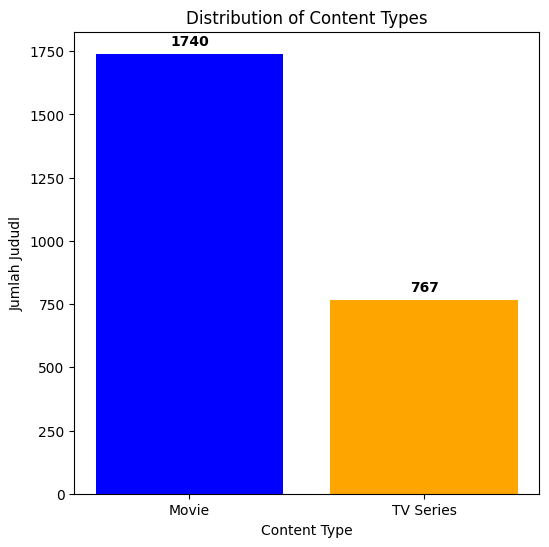

In [215]:
counts = df_bersih['Content_Type'].value_counts()

counts = df_bersih['Content_Type'].value_counts()
plt.figure(figsize=(6, 6))

bars= plt.bar(counts.index, counts.values, color=['blue', 'orange'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, f'{yval}',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Content Type')
plt.ylabel('Jumlah Jududl')
plt.title('Distribution of Content Types')

plt.show

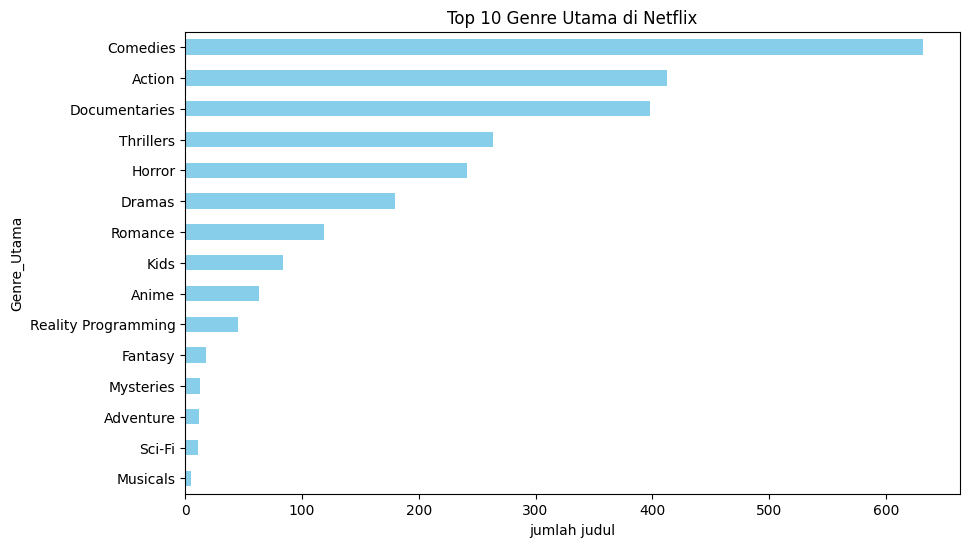

In [216]:
top_15 = df_bersih['Genre_Utama'].value_counts().head(15).sort_values()
top_15.plot(kind='barh', color='skyblue', figsize=(10, 6))
plt.title('Top 10 Genre Utama di Netflix')
plt.xlabel('jumlah judul')
plt.ylabel('Genre_Utama')
plt.show()

In [217]:
df_bersih.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2507 entries, 0 to 2634
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Film_ID       2507 non-null   int64 
 1   Title         2507 non-null   object
 2   Content_Type  2507 non-null   object
 3   Genre_Utama   2507 non-null   object
 4   Moods         2507 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.5+ KB


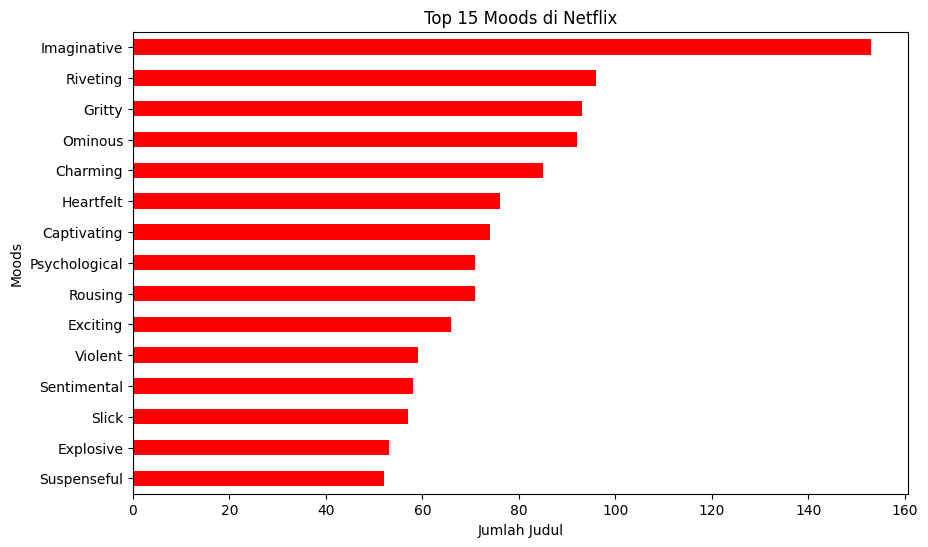

In [218]:
top_15 =df['Mood_Utama'].value_counts().head(15).sort_values()
top_15.plot(kind='barh', color='red', figsize=(10, 6))
plt.title('Top 15 Moods di Netflix')
plt.xlabel('Jumlah Judul')
plt.ylabel('Moods')
plt.show()

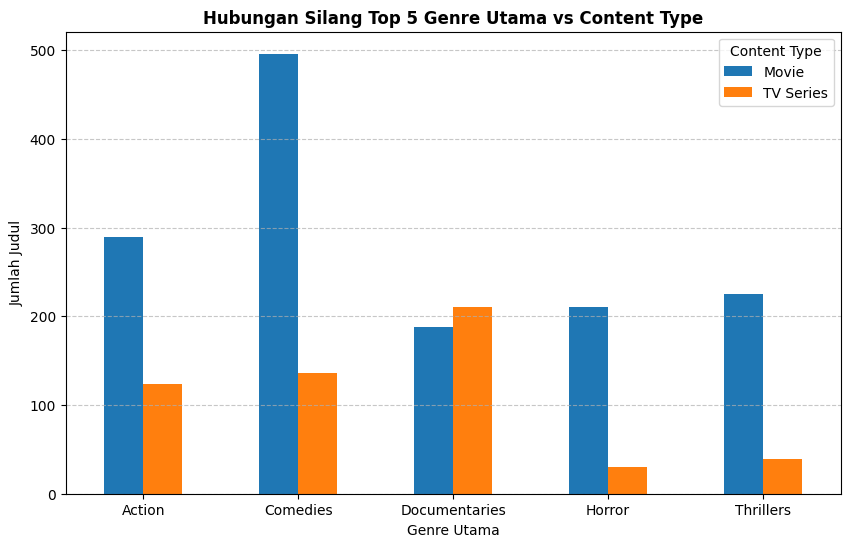

In [219]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cari 5 Genre Utama terbanyak
top_5_genres = df_bersih['Genre_Utama'].value_counts().head(5).index

# 2. Filter dataframe cuma untuk 5 genre tersebut
df_top5 = df_bersih[df_bersih['Genre_Utama'].isin(top_5_genres)]

# 3. Hitung jumlah silang antara Genre_Utama dan Content_Type
silang_genre_type = pd.crosstab(df_top5['Genre_Utama'], df_top5['Content_Type'])

# 4. Plot Grouped Bar Chart
ax = silang_genre_type.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

# 5. Atur judul dan label
plt.title('Hubungan Silang Top 5 Genre Utama vs Content Type', fontsize=12, fontweight='bold')
plt.xlabel('Genre Utama')
plt.ylabel('Jumlah Judul')
plt.xticks(rotation=0)  # Biar label genre tegak dan gampang dibaca
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


# **4. Modeling Unsupervised Learning**

In [226]:
df_ML

,Film_ID,Title,Content_Type,Genre_Utama_Action,Genre_Utama_Adventure,Genre_Utama_Anime,Genre_Utama_Comedies,Genre_Utama_Documentaries,Genre_Utama_Dramas,Genre_Utama_Fantasy,...,Mood_Utama_Swoonworthy,Mood_Utama_Teen,Mood_Utama_Telenovela,Mood_Utama_Theater,Mood_Utama_Thriller,Mood_Utama_True Crime,Mood_Utama_Understated,Mood_Utama_Violent,Mood_Utama_Whimsical,Mood_Utama_Witty
0,81266458,Time to Hunt,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,80206395,Trump: An American Dream,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,81404276,Jackass 4.5,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,81315804,Turning Point: 9/11 and the War on Terror,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,81599888,Incantation,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2502,81769466,Badly in Love,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2503,81623231,Breaking the Silence: The Maria Soledad Case,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2504,81028174,The Upshaws,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2505,80998491,After Life,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


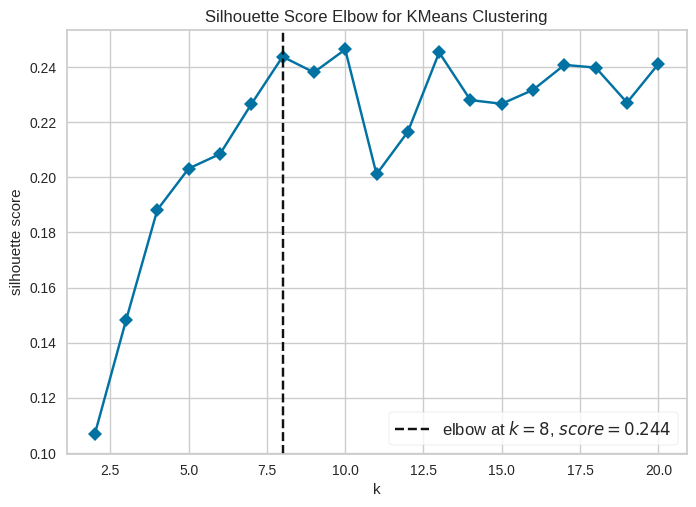

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [229]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score

X = df_ML.select_dtypes(include=['number']).drop(columns=['Film_ID'], errors='ignore')
model = KMeans(random_state=42, n_init=10)

visualizer = KElbowVisualizer(model,
                              k=(2, 21),
                              metric = 'silhouette',
                              timings= False)
visualizer.fit(X)
visualizer.show()

In [234]:
X = df_ML.select_dtypes(include=['number']).drop(columns=['Film_ID'], errors='ignore')

model = KMeans(n_clusters=8, random_state=42, n_init=10)
df_ML['Cluster'] = model.fit_predict(X)

print("=== Clustering Complete===")
print("Jumlah film per cluster:")
print(df_ML['Cluster'].value_counts().sort_index())

=== Clustering Complete===
Jumlah film per cluster:
Cluster
0    632
1    413
2    241
3    398
4    228
5    116
6    264
7    215
Name: count, dtype: int64


In [235]:
import joblib
joblib.dump(model, "model_clustering.h5")

['model_clustering.h5']